<a href="https://colab.research.google.com/github/Paulo83-dev/mestrado-computacao-aplicada/blob/main/preco_casas_passo_a_passo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Previsao de Precos de Casas com Machine Learning

**Aluno:** Paulo Fernando de Lima Filho

## Introducao

Este projeto tem como tema a aplicacao de tecnicas de Machine Learning para previsao de precos de imoveis.

O problema escolhido foi o desafio **House Prices - Advanced Regression Techniques**, disponivel no Kaggle. O objetivo e desenvolver um modelo capaz de prever o preco de venda de uma casa com base em suas caracteristicas, como area, qualidade geral, ano de construcao, numero de comodos, localizacao e outras informacoes disponiveis no dataset.

Esse problema e tratado como uma tarefa de **regressao**, pois a variavel que desejamos prever, `SalePrice`, representa um valor numerico continuo.

Ao longo do notebook, serao realizadas etapas de contextualizacao do dataset, analise exploratoria dos dados, pre-processamento, selecao de tecnicas de Machine Learning, treinamento dos modelos, avaliacao dos resultados e conclusao.

## Contextualizacao do Dataset

O dataset utilizado neste projeto e o **House Prices - Advanced Regression Techniques**, disponivel no Kaggle. Ele contem informacoes sobre imoveis residenciais, como area construida, qualidade geral, localizacao, ano de construcao, quantidade de comodos, caracteristicas da garagem e outras variaveis relacionadas ao imovel.

A variavel alvo do projeto e `SalePrice`, que representa o preco de venda da casa. Como essa variavel e numerica e continua, o problema e tratado como uma tarefa de regressao.

Em tarefas de Machine Learning, e fundamental separar os dados em conjuntos de treino e teste. O conjunto de treino e usado para o modelo aprender padroes a partir dos dados, enquanto o conjunto de teste e usado para avaliar se o modelo consegue generalizar para dados novos, que ele ainda nao viu.

Se todos os dados fossem usados apenas para treinar o modelo, poderiamos ter uma falsa impressao de bom desempenho. Nesse caso, o modelo poderia memorizar padroes especificos da base de treino, fenomeno conhecido como overfitting, e apresentar baixo desempenho quando aplicado a novos dados.

Neste desafio do Kaggle, os arquivos ja sao disponibilizados separadamente em `train.csv` e `test.csv`. O arquivo `train.csv` contem a variavel alvo `SalePrice` e sera usado para treinar e validar os modelos. O arquivo `test.csv` nao contem essa variavel, pois representa os dados para os quais o modelo deve gerar previsoes a serem submetidas ao Kaggle.

Por esse motivo, durante o desenvolvimento do projeto, o `train.csv` sera dividido internamente em treino e validacao. Assim, sera possivel avaliar os modelos usando dados com respostas conhecidas antes de gerar as previsoes finais para o `test.csv`.

## Carregamento dos Arquivos CSV

Nesta etapa, vamos carregar os arquivos `train.csv`, `test.csv` e `sample_submission.csv` para dentro do notebook.

Para isso, sera utilizada a biblioteca `pandas`, uma das bibliotecas mais usadas em projetos de analise de dados com Python. Ela permite ler arquivos tabulares, como CSV, e armazena-los em estruturas chamadas DataFrames, que facilitam a visualizacao, manipulacao e analise dos dados.

A decisao de comecar pelo carregamento dos arquivos e importante porque, antes de qualquer analise exploratoria ou treinamento de modelo, precisamos confirmar se os dados foram lidos corretamente e entender a estrutura inicial de cada arquivo.

In [3]:
# Importa o pandas, biblioteca usada para ler arquivos CSV e trabalhar com tabelas.
import pandas as pd

# Carrega os arquivos do Kaggle em DataFrames separados.
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

# Exibe a quantidade de linhas e colunas de cada arquivo carregado.
print("Dimensoes do train.csv:", train.shape)
print("Dimensoes do test.csv:", test.shape)
print("Dimensoes do sample_submission.csv:", sample_submission.shape)

Dimensoes do train.csv: (1460, 81)
Dimensoes do test.csv: (1459, 80)
Dimensoes do sample_submission.csv: (1459, 2)


## Visualizacao Inicial dos Dados

Depois de carregar os arquivos, o proximo passo e visualizar algumas linhas iniciais para entender como os dados estao organizados.

Para isso, sera utilizado o metodo `head()` do `pandas`, que mostra as primeiras linhas de um DataFrame. Essa verificacao ajuda a identificar os nomes das colunas, o tipo de informacao presente em cada arquivo e a estrutura geral dos dados antes de iniciar analises mais detalhadas.

In [4]:
# Mostra as primeiras linhas do conjunto de treino.
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# Mostra as primeiras linhas do conjunto de teste.
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [6]:
# Mostra o formato esperado do arquivo de submissao para o Kaggle.
sample_submission.head()

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


### Observacoes Iniciais

A visualizacao inicial confirma que o arquivo `train.csv` possui a coluna `SalePrice`, que representa o preco real de venda dos imoveis e sera usada como variavel alvo durante o treinamento e a avaliacao dos modelos.

O arquivo `test.csv`, por outro lado, possui as mesmas caracteristicas dos imoveis, mas nao possui a coluna `SalePrice`. Isso ocorre porque os precos reais do conjunto de teste sao ocultados pelo Kaggle, permitindo que a plataforma avalie as previsoes enviadas pelos participantes.

Tambem e possivel observar que os identificadores (`Id`) seguem uma sequencia: no conjunto de treino, os IDs comecam em 1 e seguem ate 1460; no conjunto de teste, os IDs continuam a partir de 1461. O arquivo `sample_submission.csv` usa esses mesmos IDs do conjunto de teste e apresenta a estrutura esperada para a submissao, com uma coluna `Id` e uma coluna `SalePrice`, que devera conter os valores previstos pelo modelo.

## Analise Exploratoria de Dados

A Analise Exploratoria de Dados, conhecida como EDA, tem como objetivo compreender melhor a estrutura do dataset antes da criacao dos modelos de Machine Learning.

Nesta etapa, serao investigados aspectos como tipos de dados, estatisticas descritivas, distribuicao da variavel alvo, relacoes entre variaveis, correlacoes e possiveis problemas, como valores ausentes ou presenca de outliers.

Essa analise e importante porque ajuda a orientar as decisoes de pre-processamento e tambem permite identificar quais variaveis podem ter maior influencia sobre o preco dos imoveis.

### Estrutura Geral do Conjunto de Treino

O primeiro passo da EDA sera verificar a estrutura geral do conjunto de treino. Para isso, sera utilizado o metodo `info()` do `pandas`.

Esse metodo mostra a quantidade de linhas, os nomes das colunas, os tipos de dados e a quantidade de valores nao nulos em cada coluna. Essa verificacao e importante para identificar variaveis numericas, variaveis categoricas e possiveis colunas com valores ausentes.

In [7]:
# Exibe tipos de dados, quantidade de valores nao nulos e uso de memoria.
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Interpretacao da Estrutura Geral

A funcao `info()` mostrou que o conjunto de treino possui 1460 registros e 81 colunas. Entre essas colunas, ha variaveis numericas, representadas pelos tipos `int64` e `float64`, e variaveis categoricas, representadas pelo tipo `object`.

A variavel alvo `SalePrice` esta presente no conjunto de treino e nao possui valores ausentes, o que permite utiliza-la diretamente como referencia para o treinamento e avaliacao dos modelos.

Tambem foi possivel observar que algumas colunas possuem valores ausentes. Em alguns casos, a quantidade de valores faltantes e pequena, como em `Electrical` e `MasVnrArea`. Em outros casos, a ausencia e muito maior, como em `PoolQC`, `MiscFeature`, `Alley`, `Fence` e `FireplaceQu`.

Essa observacao e importante porque indica que, antes do treinamento dos modelos, sera necessario definir estrategias de pre-processamento para lidar com valores ausentes e tambem transformar variaveis categoricas em formato numerico.

### Quantidade de Variaveis por Tipo

Depois de observar a estrutura geral do dataset, o proximo passo e resumir quantas variaveis existem de cada tipo.

Essa verificacao e importante porque o tipo das variaveis influencia diretamente as etapas futuras de pre-processamento. Variaveis numericas podem ser usadas em calculos estatisticos e modelos de regressao, enquanto variaveis categoricas precisam ser transformadas em representacoes numericas antes do treinamento dos modelos.

In [8]:
# Conta quantas colunas existem de cada tipo de dado.
train.dtypes.value_counts()

,count
object,43
int64,35
float64,3


### Interpretacao dos Tipos de Variaveis

A contagem dos tipos de dados mostra que o dataset possui 43 variaveis categoricas, 35 variaveis inteiras e 3 variaveis decimais.

Esse resultado e importante porque indica que o conjunto de dados nao e formado apenas por numeros. Diferentemente de datasets mais simples, como alguns exemplos didaticos de regressao linear, este dataset possui muitas variaveis categoricas representadas como texto.

Como a maioria dos modelos de Machine Learning trabalha com dados numericos, essas variaveis categoricas precisarao ser analisadas e transformadas antes do treinamento. No entanto, a melhor estrategia de transformacao pode variar conforme o significado de cada variavel.

Algumas variaveis categoricas podem ser nominais, ou seja, sem uma ordem natural entre as categorias. Outras podem ser ordinais, quando existe uma hierarquia entre os valores. Por isso, a escolha da tecnica de codificacao sera discutida posteriormente na etapa de pre-processamento.

Alem disso, os valores ausentes tambem deverao ser analisados com cuidado, pois nem todo `NaN` tem o mesmo significado. Em algumas colunas, ele pode indicar ausencia real de uma caracteristica; em outras, pode representar apenas falta de informacao.

### Investigacao de Valores Ausentes

Como foi observado na estrutura geral do dataset, algumas colunas possuem valores ausentes. Antes de decidir como tratar esses valores, e importante quantificar quais colunas apresentam `NaN` e qual o percentual de ausencia em cada uma.

Essa analise e necessaria porque valores ausentes podem ter significados diferentes. Em algumas variaveis, o `NaN` pode representar a ausencia real de uma caracteristica, como ausencia de piscina, garagem ou porao. Em outras, pode representar uma informacao nao coletada.

Por isso, nesta etapa ainda nao sera aplicada nenhuma correcao. O objetivo e apenas diagnosticar o problema para orientar as decisoes futuras de pre-processamento.

In [9]:
# Conta quantos valores ausentes existem em cada coluna do conjunto de treino.
missing_values = train.isna().sum()

# Calcula o percentual de valores ausentes em relacao ao total de linhas.
missing_percent = (missing_values / len(train)) * 100

# Organiza as duas informacoes em uma tabela para facilitar a leitura.
missing_summary = pd.DataFrame({
    "valores_ausentes": missing_values,
    "percentual_ausente": missing_percent
})

# Mantem apenas as colunas que possuem pelo menos um valor ausente.
missing_summary = missing_summary[missing_summary["valores_ausentes"] > 0]

# Ordena da maior para a menor proporcao de valores ausentes.
missing_summary.sort_values(by="percentual_ausente", ascending=False)

,valores_ausentes,percentual_ausente
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


### Estatisticas Descritivas das Variaveis Numericas

Depois de investigar a estrutura e os valores ausentes, o proximo passo e observar estatisticas descritivas das variaveis numericas.

Para isso, sera utilizado o metodo `describe()` do `pandas`. Ele apresenta medidas como media, desvio padrao, valor minimo, quartis e valor maximo. Essas informacoes ajudam a identificar a escala das variaveis, possiveis valores extremos e a distribuicao geral dos dados numericos.

In [10]:
# Gera estatisticas descritivas para as colunas numericas do conjunto de treino.
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Distribuicao da Variavel Alvo

A variavel alvo deste projeto e `SalePrice`, que representa o preco de venda dos imoveis. Antes de criar modelos de regressao, e importante entender como essa variavel esta distribuida.

Nesta etapa, serao usadas as bibliotecas `matplotlib` e `seaborn`, que permitem criar graficos em Python. O histograma sera utilizado para visualizar a frequencia dos precos e verificar se existe concentracao em determinadas faixas ou presenca de valores muito altos.

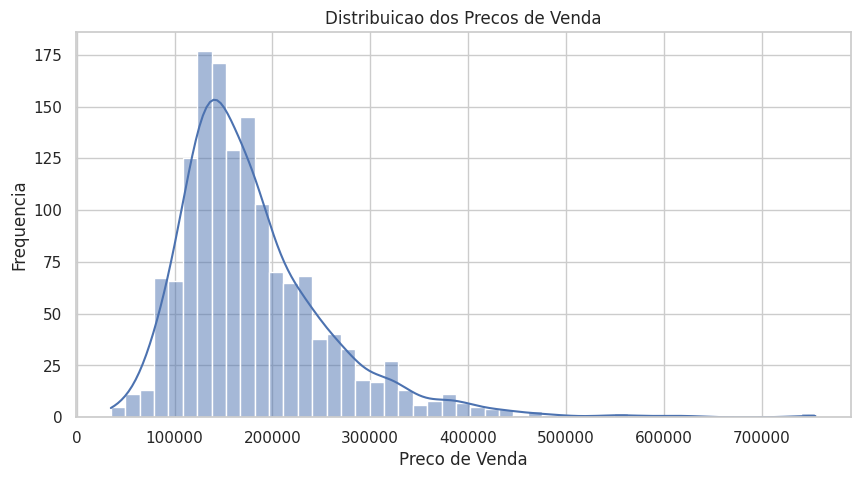

In [11]:
# Importa bibliotecas de visualizacao no momento em que elas passam a ser necessarias.
import matplotlib.pyplot as plt
import seaborn as sns

# Define um estilo visual padrao para os graficos.
sns.set_theme(style="whitegrid")

# Cria um histograma para observar a distribuicao dos precos de venda.
plt.figure(figsize=(10, 5))
sns.histplot(train["SalePrice"], kde=True)
plt.title("Distribuicao dos Precos de Venda")
plt.xlabel("Preco de Venda")
plt.ylabel("Frequencia")
plt.show()

### Correlacao com a Variavel Alvo

A correlacao ajuda a medir a intensidade da relacao linear entre variaveis numericas. Nesta etapa, vamos calcular quais variaveis numericas possuem maior correlacao com `SalePrice`.

Essa analise nao prova causalidade, mas ajuda a identificar atributos que podem ser importantes para a previsao do preco dos imoveis.

In [12]:
# Seleciona apenas colunas numericas, pois a correlacao de Pearson depende de valores numericos.
numeric_columns = train.select_dtypes(include=["int64", "float64"]).columns

# Calcula a correlacao de cada variavel numerica com a variavel alvo SalePrice.
saleprice_correlations = train[numeric_columns].corr()["SalePrice"].sort_values(ascending=False)

# Exibe as variaveis numericas mais correlacionadas com o preco de venda.
saleprice_correlations.head(12)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


### Relacao entre Area Habitavel e Preco

A variavel `GrLivArea` representa a area habitavel acima do solo. Como area e um fator naturalmente associado ao valor de um imovel, vamos visualizar sua relacao com `SalePrice` por meio de um grafico de dispersao.

Esse grafico tambem pode ajudar a identificar possiveis outliers, como casas com area muito grande, mas preco relativamente baixo.

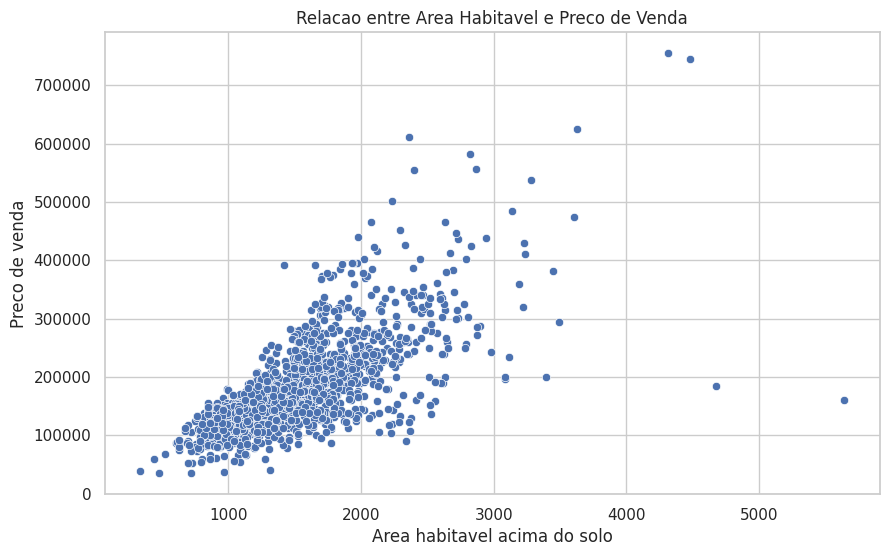

In [13]:
# Cria um grafico de dispersao para comparar area habitavel e preco de venda.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice")
plt.title("Relacao entre Area Habitavel e Preco de Venda")
plt.xlabel("Area habitavel acima do solo")
plt.ylabel("Preco de venda")
plt.show()

### Relacao entre Qualidade Geral e Preco

A variavel `OverallQual` representa a qualidade geral do material e do acabamento do imovel. Como essa variavel e uma avaliacao ordinal, espera-se que valores maiores estejam associados a precos maiores.

Para observar esse padrao, sera utilizado um boxplot, que permite comparar a distribuicao dos precos em cada nivel de qualidade.

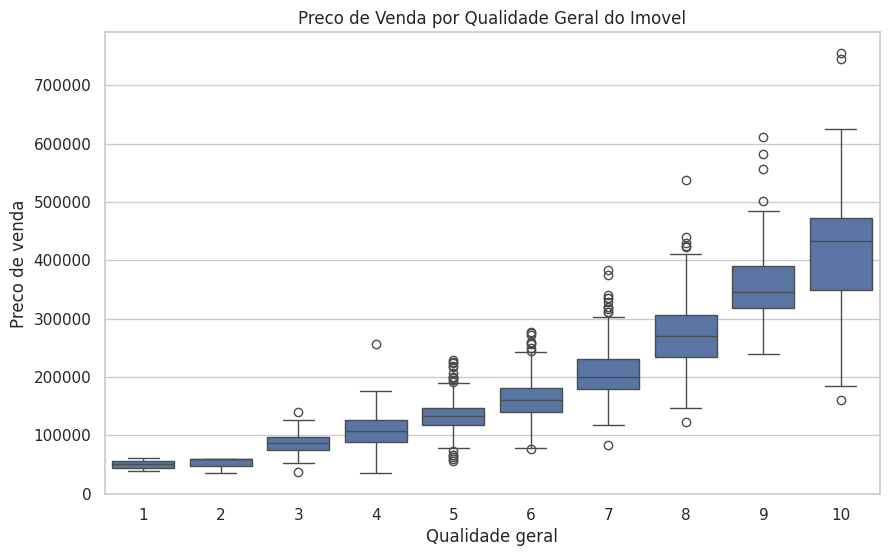

In [14]:
# Cria um boxplot para comparar precos entre os niveis de qualidade geral.
plt.figure(figsize=(10, 6))
sns.boxplot(data=train, x="OverallQual", y="SalePrice")
plt.title("Preco de Venda por Qualidade Geral do Imovel")
plt.xlabel("Qualidade geral")
plt.ylabel("Preco de venda")
plt.show()

### Interpretacao das Correlacoes e Graficos

A analise de correlacao mostrou que `OverallQual` e a variavel numerica mais associada ao preco de venda, com correlacao aproximada de 0.79. Isso indica que a qualidade geral do imovel tem forte relacao positiva com `SalePrice`.

A variavel `GrLivArea`, que representa a area habitavel acima do solo, tambem apresentou forte correlacao com o preco, com valor aproximado de 0.71. O grafico de dispersao confirma esse padrao, mostrando que, em geral, imoveis com maior area habitavel tendem a apresentar precos maiores.

Outras variaveis relacionadas a garagem, porao, quantidade de banheiros, quantidade de comodos e ano de construcao tambem aparecem entre as mais correlacionadas com o preco, indicando que caracteristicas estruturais e de qualidade do imovel sao importantes para a previsao.

O boxplot entre `OverallQual` e `SalePrice` reforca esse comportamento: conforme a qualidade geral aumenta, a mediana dos precos tambem aumenta. Isso sugere que `OverallQual` provavelmente sera uma variavel relevante para os modelos de Machine Learning.

Tambem foram observados possiveis outliers, especialmente no grafico entre `GrLivArea` e `SalePrice`, onde alguns imoveis apresentam area muito alta, mas preco relativamente baixo. Esses casos devem ser analisados com cuidado, pois podem influenciar o desempenho de determinados modelos.

### Sintese da Analise Exploratoria

A Analise Exploratoria de Dados permitiu identificar caracteristicas importantes do dataset antes da criacao dos modelos.

O conjunto de treino possui 1460 registros e 81 colunas, incluindo a variavel alvo `SalePrice`. O conjunto de teste possui 1459 registros e nao contem a variavel alvo, pois os precos reais sao ocultados pelo Kaggle para avaliacao das submissoes.

Foi observado que o dataset possui muitas variaveis categoricas e numericas. Essa caracteristica indica que o pre-processamento sera uma etapa importante, pois as variaveis categoricas precisarao ser analisadas conforme seu significado antes de serem transformadas para uso nos modelos.

Tambem foram identificados valores ausentes em diversas colunas. Em alguns casos, esses valores podem indicar ausencia real de uma caracteristica do imovel, como piscina, garagem, porao ou cerca. Em outros casos, podem representar falta de informacao. Por isso, o tratamento dos valores ausentes devera considerar o significado de cada variavel.

A variavel alvo `SalePrice` apresenta diferencas relevantes entre os imoveis, e as analises de correlacao indicam que variaveis como `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea` e `TotalBsmtSF` possuem forte relacao com o preco de venda.

Os graficos tambem mostraram padroes importantes: casas com maior area habitavel tendem a ter maior preco, e imoveis com melhor qualidade geral apresentam precos mais altos. Alem disso, foram observados possiveis outliers, que deverao ser considerados nas proximas etapas.

Com base nesses achados, a proxima etapa sera o pre-processamento dos dados, incluindo o tratamento de valores ausentes, a analise das variaveis categoricas e a preparacao dos dados para os modelos de Machine Learning.

## Pre-processamento dos Dados

A etapa de pre-processamento tem como objetivo preparar os dados para que possam ser utilizados pelos modelos de Machine Learning.

A Analise Exploratoria de Dados mostrou que o dataset possui valores ausentes, variaveis numericas em escalas diferentes e muitas variaveis categoricas. Esses pontos precisam ser tratados antes do treinamento, pois modelos de Machine Learning geralmente esperam dados completos e em formato numerico.

Nesta etapa, serao tomadas decisoes sobre:

- separacao entre variaveis explicativas e variavel alvo;
- divisao interna do conjunto de treino em treino e validacao;
- tratamento de valores ausentes;
- transformacao de variaveis categoricas;
- possivel normalizacao ou padronizacao de variaveis numericas.

As decisoes de pre-processamento serao feitas com cuidado, pois nem todo valor ausente possui o mesmo significado e nem toda variavel categorica deve ser tratada da mesma forma.

### Separacao entre Variaveis Explicativas e Variavel Alvo

Antes de treinar qualquer modelo, e necessario separar a variavel que desejamos prever das variaveis que serao usadas como entrada.

Neste projeto, a variavel alvo e `SalePrice`, pois representa o preco de venda dos imoveis. Ela sera armazenada em `y`.

As demais variaveis serao usadas como explicativas e armazenadas em `X`. A coluna `Id` sera removida de `X`, pois funciona apenas como identificador do registro e nao representa uma caracteristica do imovel que ajude a explicar o preco.

Essa separacao tambem deixa o fluxo do projeto mais organizado para as proximas etapas, como divisao treino/validacao, pre-processamento e treinamento dos modelos.

In [15]:
# Separa a variavel alvo, que e o preco de venda dos imoveis.
y = train["SalePrice"]

# Remove a variavel alvo e o identificador Id das variaveis explicativas.
X = train.drop(columns=["SalePrice", "Id"])

# Remove o identificador Id do conjunto de teste usado para previsoes finais.
X_test = test.drop(columns=["Id"])

# Confere as dimensoes dos objetos que serao usados nas proximas etapas.
print("Dimensoes de X:", X.shape)
print("Dimensoes de y:", y.shape)
print("Dimensoes de X_test:", X_test.shape)

Dimensoes de X: (1460, 79)
Dimensoes de y: (1460,)
Dimensoes de X_test: (1459, 79)


### Interpretacao da Separacao dos Dados

Apos a separacao, `X` ficou com 1460 registros e 79 variaveis explicativas. A variavel alvo `SalePrice` foi removida de `X` e armazenada separadamente em `y`.

A coluna `Id` tambem foi removida porque funciona apenas como identificador dos registros, nao como uma caracteristica do imovel.

O conjunto `X_test` ficou com 1459 registros e as mesmas 79 variaveis explicativas de `X`. Isso confirma que os dados de treino e teste estao alinhados para que, ao final, o modelo treinado possa gerar previsoes para os imoveis do conjunto de teste.

### Divisao entre Treino e Validacao

Como o arquivo `test.csv` nao possui a variavel alvo `SalePrice`, ele nao pode ser usado diretamente para avaliar o desempenho dos modelos durante o desenvolvimento.

Por isso, o conjunto de treino original sera dividido internamente em duas partes: uma parte para treinar os modelos e outra para validar os resultados.

A divisao sera feita com a funcao `train_test_split` da biblioteca `scikit-learn`. Essa funcao permite separar os dados de forma controlada, mantendo uma parte reservada para avaliar se o modelo consegue generalizar para dados que nao foram usados no treinamento.

Neste projeto, sera utilizada uma divisao de 80% dos dados para treino e 20% para validacao. Tambem sera definido um `random_state` para garantir que a divisao possa ser reproduzida em outras execucoes.

In [16]:
# Importa a funcao usada para dividir os dados em treino e validacao.
from sklearn.model_selection import train_test_split

# Divide os dados em 80% para treino e 20% para validacao.
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Confere as dimensoes dos conjuntos criados.
print("Dimensoes de X_train:", X_train.shape)
print("Dimensoes de X_valid:", X_valid.shape)
print("Dimensoes de y_train:", y_train.shape)
print("Dimensoes de y_valid:", y_valid.shape)

Dimensoes de X_train: (1168, 79)
Dimensoes de X_valid: (292, 79)
Dimensoes de y_train: (1168,)
Dimensoes de y_valid: (292,)


### Interpretacao da Divisao entre Treino e Validacao

A divisao criou 1168 registros para treino e 292 registros para validacao, mantendo as 79 variaveis explicativas.

O conjunto `X_train` sera usado para ajustar os modelos, enquanto `X_valid` sera usado para avaliar o desempenho em dados que nao participaram do treinamento.

Da mesma forma, `y_train` contem os precos reais dos registros de treino, e `y_valid` contem os precos reais dos registros de validacao.

Essa separacao permite medir a capacidade de generalizacao dos modelos antes de gerar previsoes para o conjunto `test.csv` do Kaggle.

### Estrategia para Tratamento de Valores Ausentes

A EDA mostrou que existem valores ausentes em diferentes colunas do dataset. No entanto, esses valores nao devem ser tratados todos da mesma forma.

Em algumas colunas, o valor ausente representa a ausencia real de uma caracteristica do imovel. Por exemplo, `PoolQC` ausente pode indicar que o imovel nao possui piscina; colunas relacionadas a garagem ausentes podem indicar ausencia de garagem; e colunas relacionadas ao porao ausentes podem indicar ausencia de porao.

Em outros casos, o valor ausente pode indicar apenas falta de informacao registrada, como ocorre com variaveis numericas como `LotFrontage`.

Por esse motivo, o tratamento sera dividido em estrategias diferentes, considerando o significado de cada coluna. Essa decisao evita transformar automaticamente todo `NaN` em zero ou remover colunas sem analisar seu contexto.

### Classificacao Inicial dos Valores Ausentes

Antes de aplicar qualquer imputacao, vamos separar os valores ausentes em grupos conforme seu significado provavel.

Com base na descricao do dataset, algumas colunas usam `NaN` para indicar que o imovel nao possui determinada caracteristica. Nesses casos, o valor ausente nao e exatamente um erro, mas uma informacao relevante.

Outras colunas parecem representar informacoes que nao foram registradas. Nesses casos, sera necessario preencher os valores ausentes usando alguma estrategia, como mediana para variaveis numericas ou moda para variaveis categoricas.

Essa classificacao ajuda a justificar o tratamento aplicado posteriormente.

In [17]:
# Colunas em que NaN provavelmente representa ausencia real da caracteristica.
none_columns = [
    "Alley",        # Tipo de acesso por beco. NaN indica sem acesso por beco.
    "PoolQC",       # Qualidade da piscina. NaN indica sem piscina.
    "Fence",        # Qualidade da cerca. NaN indica sem cerca.
    "MiscFeature",  # Caracteristica extra do imovel. NaN indica sem caracteristica extra.
    "FireplaceQu",  # Qualidade da lareira. NaN indica sem lareira.
    "GarageType",   # Tipo de garagem. NaN indica sem garagem.
    "GarageFinish", # Acabamento interno da garagem. NaN indica sem garagem.
    "GarageQual",   # Qualidade da garagem. NaN indica sem garagem.
    "GarageCond",   # Condicao da garagem. NaN indica sem garagem.
    "BsmtQual",     # Qualidade do porao. NaN indica sem porao.
    "BsmtCond",     # Condicao do porao. NaN indica sem porao.
    "BsmtExposure", # Exposicao do porao. NaN indica sem porao.
    "BsmtFinType1", # Tipo da area acabada principal do porao. NaN indica sem porao.
    "BsmtFinType2", # Tipo da segunda area acabada do porao. NaN indica sem porao.
    "MasVnrType"    # Tipo de revestimento de alvenaria. NaN pode indicar ausencia desse revestimento.
]

# Colunas numericas em que NaN provavelmente representa informacao faltante.
numeric_missing_columns = [
    "LotFrontage", # Comprimento da fachada ligada a rua. NaN sugere informacao nao registrada.
    "MasVnrArea",  # Area do revestimento de alvenaria. NaN sugere informacao faltante ou ausencia.
    "GarageYrBlt"  # Ano de construcao da garagem. NaN pode estar ligado a ausencia de garagem.
]

# Colunas categoricas com poucos valores ausentes que podem ser preenchidas pela moda.
categorical_missing_columns = [
    "Electrical" # Sistema eletrico. Possui poucos NaN, provavelmente informacao faltante.
]

# Mostra a quantidade de colunas em cada grupo de tratamento.
print("Colunas com NaN estrutural:", len(none_columns))
print("Colunas numericas com NaN:", len(numeric_missing_columns))
print("Colunas categoricas com poucos NaN:", len(categorical_missing_columns))

Colunas com NaN estrutural: 15
Colunas numericas com NaN: 3
Colunas categoricas com poucos NaN: 1


### Tratamento Inicial dos Valores Ausentes

Com as colunas de valores ausentes classificadas, o proximo passo e aplicar o tratamento inicial.

Para as colunas em que `NaN` representa ausencia real de uma caracteristica, os valores ausentes serao preenchidos com `"None"`. Essa escolha preserva a informacao de que o imovel nao possui aquela caracteristica, em vez de tratar o valor como erro.

Para as colunas numericas com valores ausentes, sera utilizada uma estrategia mais cautelosa. Neste momento, `LotFrontage` e `MasVnrArea` serao preenchidas com a mediana calculada no conjunto de treino. A mediana e escolhida por ser menos sensivel a valores extremos do que a media.

A coluna `GarageYrBlt` exige cuidado, pois seus valores ausentes provavelmente estao relacionados a imoveis sem garagem. Por isso, ela sera preenchida com `0`, indicando ausencia de ano de construcao da garagem.

A coluna `Electrical`, que possui poucos valores ausentes, sera preenchida com a moda do conjunto de treino, ou seja, o valor mais frequente.

Todas essas estatisticas serao calculadas usando apenas `X_train`, para evitar vazamento de dados para o conjunto de validacao.

Como o conjunto `test.csv` tambem pode possuir valores ausentes em colunas que nao apareceram com `NaN` no treino, sera aplicada uma verificacao final. Caso ainda existam valores ausentes, variaveis numericas serao preenchidas com a mediana do treino e variaveis categoricas com a moda do treino.

In [18]:
# Cria copias dos conjuntos para preservar os dados originais.
X_train_processed = X_train.copy()
X_valid_processed = X_valid.copy()
X_test_processed = X_test.copy()

# Preenche NaN estruturais com "None", indicando ausencia da caracteristica.
for column in none_columns:
    X_train_processed[column] = X_train_processed[column].fillna("None")
    X_valid_processed[column] = X_valid_processed[column].fillna("None")
    X_test_processed[column] = X_test_processed[column].fillna("None")

# Preenche LotFrontage e MasVnrArea com a mediana calculada apenas no treino.
for column in ["LotFrontage", "MasVnrArea"]:
    median_value = X_train_processed[column].median()

    X_train_processed[column] = X_train_processed[column].fillna(median_value)
    X_valid_processed[column] = X_valid_processed[column].fillna(median_value)
    X_test_processed[column] = X_test_processed[column].fillna(median_value)

# Preenche GarageYrBlt com 0 para representar ausencia de garagem/ano de garagem.
X_train_processed["GarageYrBlt"] = X_train_processed["GarageYrBlt"].fillna(0)
X_valid_processed["GarageYrBlt"] = X_valid_processed["GarageYrBlt"].fillna(0)
X_test_processed["GarageYrBlt"] = X_test_processed["GarageYrBlt"].fillna(0)

# Preenche Electrical com a moda calculada apenas no treino.
electrical_mode = X_train_processed["Electrical"].mode()[0]

X_train_processed["Electrical"] = X_train_processed["Electrical"].fillna(electrical_mode)
X_valid_processed["Electrical"] = X_valid_processed["Electrical"].fillna(electrical_mode)
X_test_processed["Electrical"] = X_test_processed["Electrical"].fillna(electrical_mode)

# Identifica colunas numericas e categoricas para uma verificacao final de valores ausentes.
numeric_features = X_train_processed.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train_processed.select_dtypes(include=["object"]).columns

# Preenche eventuais NaN restantes em colunas numericas usando medianas calculadas no treino.
for column in numeric_features:
    if X_train_processed[column].isna().any() or X_valid_processed[column].isna().any() or X_test_processed[column].isna().any():
        median_value = X_train_processed[column].median()

        X_train_processed[column] = X_train_processed[column].fillna(median_value)
        X_valid_processed[column] = X_valid_processed[column].fillna(median_value)
        X_test_processed[column] = X_test_processed[column].fillna(median_value)

# Preenche eventuais NaN restantes em colunas categoricas usando modas calculadas no treino.
for column in categorical_features:
    if X_train_processed[column].isna().any() or X_valid_processed[column].isna().any() or X_test_processed[column].isna().any():
        mode_value = X_train_processed[column].mode()[0]

        X_train_processed[column] = X_train_processed[column].fillna(mode_value)
        X_valid_processed[column] = X_valid_processed[column].fillna(mode_value)
        X_test_processed[column] = X_test_processed[column].fillna(mode_value)

# Verifica se ainda existem valores ausentes nos conjuntos processados.
print("Valores ausentes em X_train_processed:", X_train_processed.isna().sum().sum())
print("Valores ausentes em X_valid_processed:", X_valid_processed.isna().sum().sum())
print("Valores ausentes em X_test_processed:", X_test_processed.isna().sum().sum())

Valores ausentes em X_train_processed: 0
Valores ausentes em X_valid_processed: 0
Valores ausentes em X_test_processed: 0


### Interpretacao do Tratamento de Valores Ausentes

Apos o tratamento inicial, os conjuntos `X_train_processed`, `X_valid_processed` e `X_test_processed` ficaram sem valores ausentes.

As colunas em que `NaN` representava ausencia real de uma caracteristica foram preenchidas com `"None"`, preservando a informacao de que o imovel nao possui aquele recurso, como piscina, garagem, porao, cerca ou lareira.

As colunas numericas com valores ausentes foram preenchidas com valores calculados a partir do conjunto de treino. Em geral, foi utilizada a mediana, por ser menos sensivel a valores extremos do que a media.

A coluna `GarageYrBlt` recebeu tratamento especifico, sendo preenchida com `0` quando o ano da garagem estava ausente, pois essa ausencia pode estar associada a imoveis sem garagem.

A coluna `Electrical`, por possuir poucos valores ausentes, foi preenchida com a moda do conjunto de treino, ou seja, o valor mais frequente.

Tambem foi feita uma verificacao final para garantir que eventuais valores ausentes presentes apenas no conjunto de teste fossem tratados com estatisticas calculadas no treino.

Esse cuidado evita vazamento de dados e garante que os tres conjuntos estejam prontos para as proximas etapas de codificacao de variaveis categoricas e modelagem.

### Classificacao das Variaveis Categoricas

Depois do tratamento dos valores ausentes, o proximo passo e preparar as variaveis categoricas para os modelos de Machine Learning.

Variaveis categoricas podem ser de tipos diferentes. Algumas sao nominais, ou seja, representam categorias sem ordem natural, como bairro, tipo de telhado ou tipo de venda. Outras sao ordinais, pois possuem uma hierarquia clara entre os valores, como qualidade excelente, boa, regular ou ruim.

Essa diferenca e importante porque variaveis ordinais podem ser convertidas para numeros preservando sua ordem. Ja variaveis nominais geralmente precisam de outra estrategia, pois atribuir numeros sequenciais poderia criar uma ordem artificial que nao existe.

Nesta etapa, vamos separar as variaveis categoricas em dois grupos: ordinais e nominais. A decisao foi baseada na descricao das variaveis no arquivo `data_description.txt`.

In [19]:
# Variaveis categoricas ordinais, pois possuem uma ordem natural entre os valores.
ordinal_columns = [
    "ExterQual",     # Qualidade externa: Ex > Gd > TA > Fa > Po
    "ExterCond",     # Condicao externa: Ex > Gd > TA > Fa > Po
    "BsmtQual",      # Qualidade/altura do porao: Ex > Gd > TA > Fa > Po > None
    "BsmtCond",      # Condicao do porao: Ex > Gd > TA > Fa > Po > None
    "BsmtExposure",  # Exposicao do porao: Gd > Av > Mn > No > None
    "BsmtFinType1",  # Qualidade da area acabada principal do porao
    "BsmtFinType2",  # Qualidade da segunda area acabada do porao
    "HeatingQC",     # Qualidade do sistema de aquecimento
    "KitchenQual",   # Qualidade da cozinha
    "FireplaceQu",   # Qualidade da lareira
    "GarageFinish",  # Acabamento interno da garagem
    "GarageQual",    # Qualidade da garagem
    "GarageCond",    # Condicao da garagem
    "PoolQC",        # Qualidade da piscina
    "Fence"          # Qualidade da cerca
]

# Variaveis categoricas nominais: categorias sem ordem natural.
nominal_columns = [
    column for column in X_train_processed.select_dtypes(include=["object"]).columns
    if column not in ordinal_columns
]

# Confere a quantidade de variaveis em cada grupo.
print("Quantidade de variaveis ordinais:", len(ordinal_columns))
print("Quantidade de variaveis nominais:", len(nominal_columns))
print("Total de variaveis categoricas:", len(ordinal_columns) + len(nominal_columns))

Quantidade de variaveis ordinais: 15
Quantidade de variaveis nominais: 28
Total de variaveis categoricas: 43


### Codificacao das Variaveis Ordinais

As variaveis ordinais possuem categorias com uma ordem natural. Por isso, elas podem ser convertidas para numeros de forma que a hierarquia seja preservada.

Por exemplo, em variaveis de qualidade, `Ex` representa excelente, `Gd` representa bom, `TA` representa medio/tipico, `Fa` representa razoavel e `Po` representa ruim. Quando a caracteristica esta ausente, foi utilizado o valor `None`, que sera codificado como `0`.

Essa abordagem e diferente de simplesmente aplicar uma codificacao qualquer, pois os numeros escolhidos representam uma relacao de ordem entre as categorias.

A codificacao sera aplicada nos conjuntos de treino, validacao e teste processados.

In [20]:
# Cria copias para armazenar os dados com variaveis ordinais codificadas.
X_train_encoded = X_train_processed.copy()
X_valid_encoded = X_valid_processed.copy()
X_test_encoded = X_test_processed.copy()

# Mapeamento para variaveis de qualidade e condicao.
quality_mapping = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

# Mapeamento para exposicao do porao.
basement_exposure_mapping = {
    "None": 0,
    "No": 1,
    "Mn": 2,
    "Av": 3,
    "Gd": 4
}

# Mapeamento para tipo de acabamento do porao.
basement_finish_mapping = {
    "None": 0,
    "Unf": 1,
    "LwQ": 2,
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6
}

# Mapeamento para acabamento da garagem.
garage_finish_mapping = {
    "None": 0,
    "Unf": 1,
    "RFn": 2,
    "Fin": 3
}

# Mapeamento para qualidade da cerca.
fence_mapping = {
    "None": 0,
    "MnWw": 1,
    "GdWo": 2,
    "MnPrv": 3,
    "GdPrv": 4
}

# Aplica mapeamento de qualidade/condicao.
quality_columns = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC"
]

for column in quality_columns:
    X_train_encoded[column] = X_train_encoded[column].map(quality_mapping)
    X_valid_encoded[column] = X_valid_encoded[column].map(quality_mapping)
    X_test_encoded[column] = X_test_encoded[column].map(quality_mapping)

# Aplica mapeamentos ordinais especificos.
for dataset in [X_train_encoded, X_valid_encoded, X_test_encoded]:
    dataset["BsmtExposure"] = dataset["BsmtExposure"].map(basement_exposure_mapping)
    dataset["BsmtFinType1"] = dataset["BsmtFinType1"].map(basement_finish_mapping)
    dataset["BsmtFinType2"] = dataset["BsmtFinType2"].map(basement_finish_mapping)
    dataset["GarageFinish"] = dataset["GarageFinish"].map(garage_finish_mapping)
    dataset["Fence"] = dataset["Fence"].map(fence_mapping)

# Confere se as variaveis ordinais foram convertidas para formato numerico.
X_train_encoded[ordinal_columns].head()

,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,HeatingQC,KitchenQual,FireplaceQu,GarageFinish,GarageQual,GarageCond,PoolQC,Fence
254,3,4,3,3,1,3,1,3,3,0,2,3,3,0,0
1066,4,3,4,3,1,1,1,4,3,3,2,3,3,0,0
638,3,3,2,3,1,1,1,4,3,0,0,0,0,0,3
799,3,3,4,3,1,5,1,5,4,3,1,3,3,0,3
380,3,3,3,3,1,2,1,3,4,4,1,3,3,0,0


### Codificacao das Variaveis Nominais

As variaveis nominais representam categorias sem ordem natural. Por exemplo, `Neighborhood` indica o bairro do imovel, mas nao existe uma ordem numerica direta entre os bairros.

Por isso, nao seria adequado substituir cada categoria por numeros sequenciais, como 1, 2, 3, pois isso poderia criar uma hierarquia artificial.

Para essas variaveis, sera utilizada a tecnica de One-Hot Encoding. Essa tecnica transforma cada categoria em uma coluna binaria, indicando a presenca ou ausencia daquela categoria.

A codificacao sera feita com `pd.get_dummies()`. Para evitar desalinhamento entre treino, validacao e teste, os tres conjuntos serao unidos temporariamente, codificados juntos e depois separados novamente.

Neste projeto, foi utilizado `drop_first=False`, mantendo uma coluna para cada categoria. Essa decisao torna a codificacao mais explicita e facilita a interpretacao didatica do notebook. Em modelos lineares puros, uma alternativa seria usar `drop_first=True`, removendo uma categoria de referencia para reduzir redundancia entre colunas. No entanto, como tambem serao testados modelos baseados em arvores e modelos lineares regularizados, manter todas as categorias e uma escolha aceitavel para esta etapa do projeto.

In [21]:
# Guarda a quantidade de linhas de cada conjunto antes da uniao.
n_train = X_train_encoded.shape[0]
n_valid = X_valid_encoded.shape[0]
n_test = X_test_encoded.shape[0]

# Une treino, validacao e teste para garantir as mesmas colunas apos o One-Hot Encoding.
combined_data = pd.concat(
    [X_train_encoded, X_valid_encoded, X_test_encoded],
    axis=0
)

# Aplica One-Hot Encoding apenas nas variaveis nominais.
combined_data_encoded = pd.get_dummies(
    combined_data,
    columns=nominal_columns,
    drop_first=False
)

# Separa novamente os conjuntos codificados.
X_train_encoded = combined_data_encoded.iloc[:n_train].copy()
X_valid_encoded = combined_data_encoded.iloc[n_train:n_train + n_valid].copy()
X_test_encoded = combined_data_encoded.iloc[n_train + n_valid:].copy()

# Confere as dimensoes apos a criacao das colunas binarias.
print("Dimensoes de X_train_encoded:", X_train_encoded.shape)
print("Dimensoes de X_valid_encoded:", X_valid_encoded.shape)
print("Dimensoes de X_test_encoded:", X_test_encoded.shape)

Dimensoes de X_train_encoded: (1168, 239)
Dimensoes de X_valid_encoded: (292, 239)
Dimensoes de X_test_encoded: (1459, 239)


### Interpretacao da Codificacao das Variaveis Categoricas

Apos a codificacao das variaveis categoricas, os conjuntos `X_train_encoded`, `X_valid_encoded` e `X_test_encoded` passaram a ter 239 colunas.

Esse aumento no numero de colunas ocorreu principalmente por causa do One-Hot Encoding aplicado nas variaveis nominais. Como cada categoria e transformada em uma coluna binaria, variaveis com varias categorias, como `Neighborhood`, aumentam a dimensionalidade do dataset.

As variaveis ordinais foram tratadas de forma diferente, recebendo valores numericos que preservam sua ordem natural. Isso evita perder a hierarquia existente em categorias como qualidade excelente, boa, regular ou ruim.

Ao final dessa etapa, os tres conjuntos ficaram alinhados, sem valores ausentes e sem variaveis textuais. Isso significa que os dados ja estao em formato numerico e podem ser utilizados pelos modelos de Machine Learning.

### Padronizacao para Modelos Sensiveis a Escala

Depois do tratamento de valores ausentes e da codificacao das variaveis categoricas, os dados ja estao em formato numerico. No entanto, algumas tecnicas de Machine Learning sao sensiveis a escala das variaveis.

Modelos lineares, como Regressao Linear, Ridge e Lasso, podem ser influenciados por diferencas de escala entre as variaveis. Por exemplo, uma variavel como `LotArea` possui valores muito maiores do que colunas binarias criadas pelo One-Hot Encoding.

Por outro lado, modelos baseados em arvores, como Decision Tree, Random Forest e Gradient Boosting, geralmente nao precisam de padronizacao, pois fazem divisoes baseadas em valores das variaveis e nao dependem diretamente da escala.

Por esse motivo, serao mantidas duas versoes dos dados:

- uma versao codificada, mas sem padronizacao, para modelos baseados em arvores;
- uma versao codificada e padronizada, para modelos sensiveis a escala.

Essa decisao permite comparar diferentes tecnicas respeitando as caracteristicas de cada tipo de modelo.

In [22]:
# Importa o StandardScaler, usado para padronizar variaveis numericas.
from sklearn.preprocessing import StandardScaler

# Cria copias para armazenar as versoes padronizadas dos dados.
X_train_scaled = X_train_encoded.copy()
X_valid_scaled = X_valid_encoded.copy()
X_test_scaled = X_test_encoded.copy()

# Identifica todas as colunas numericas apos a codificacao.
numeric_columns_encoded = X_train_scaled.select_dtypes(include=["int64", "float64", "bool"]).columns

# Cria o padronizador.
scaler = StandardScaler()

# Ajusta o scaler apenas no treino e transforma treino, validacao e teste.
X_train_scaled[numeric_columns_encoded] = scaler.fit_transform(X_train_scaled[numeric_columns_encoded])
X_valid_scaled[numeric_columns_encoded] = scaler.transform(X_valid_scaled[numeric_columns_encoded])
X_test_scaled[numeric_columns_encoded] = scaler.transform(X_test_scaled[numeric_columns_encoded])

# Confere as dimensoes das versoes padronizadas.
print("Dimensoes de X_train_scaled:", X_train_scaled.shape)
print("Dimensoes de X_valid_scaled:", X_valid_scaled.shape)
print("Dimensoes de X_test_scaled:", X_test_scaled.shape)

Dimensoes de X_train_scaled: (1168, 239)
Dimensoes de X_valid_scaled: (292, 239)
Dimensoes de X_test_scaled: (1459, 239)


### Sintese do Pre-processamento

Nesta etapa, os dados foram preparados para serem utilizados pelos modelos de Machine Learning.

Primeiro, a variavel alvo `SalePrice` foi separada das variaveis explicativas. A coluna `Id` foi removida por representar apenas um identificador, sem significado preditivo direto.

Em seguida, o conjunto de treino foi dividido em treino e validacao. Essa divisao foi feita antes do ajuste das transformacoes para evitar vazamento de dados e permitir avaliar a capacidade de generalizacao dos modelos.

Os valores ausentes foram tratados conforme seu significado. Em colunas onde `NaN` representava ausencia real de uma caracteristica, como piscina, garagem, porao, cerca ou lareira, foi utilizado o valor `"None"`. Em variaveis numericas, foram usadas estrategias como mediana calculada no treino, e em variaveis categoricas com poucos ausentes foi utilizada a moda do treino.

As variaveis categoricas foram separadas em ordinais e nominais. As ordinais foram codificadas com mapas numericos que preservam sua hierarquia. As nominais foram codificadas com One-Hot Encoding, evitando criar uma ordem artificial entre categorias sem hierarquia natural.

Por fim, foram mantidas duas versoes dos dados: uma versao apenas codificada, para modelos baseados em arvores, e outra versao codificada e padronizada, para modelos sensiveis a escala, como modelos lineares.

Ao final do pre-processamento, os dados ficaram sem valores ausentes, sem variaveis textuais e prontos para a etapa de selecao, treinamento e avaliacao dos modelos.

## Selecao e Justificativa das Tecnicas de Machine Learning

Depois do pre-processamento, a proxima etapa e escolher quais tecnicas de Machine Learning serao utilizadas.

Como a variavel alvo `SalePrice` representa um valor numerico continuo, este projeto e um problema de **regressao**. Portanto, os modelos escolhidos devem ser capazes de prever valores numericos, e nao classes ou categorias.

Para tornar a comparacao mais didatica, os modelos serao organizados em dois grupos:

1. **Modelos sensiveis a escala das variaveis**, como modelos lineares. Para eles, sera usada a versao padronizada dos dados: `X_train_scaled` e `X_valid_scaled`.

2. **Modelos baseados em arvores**, que geralmente nao precisam de padronizacao. Para eles, sera usada a versao codificada, mas sem padronizacao: `X_train_encoded` e `X_valid_encoded`.

Essa separacao permite comparar tecnicas diferentes de forma mais justa, respeitando as caracteristicas de cada tipo de modelo.

A avaliacao sera feita no conjunto de validacao, usando metricas adequadas para regressao. Assim, sera possivel comparar os modelos e justificar a escolha daquele que apresentar melhor desempenho.

### Modelos Escolhidos

Nesta etapa, serao testados modelos com diferentes niveis de complexidade. A ideia e comecar por modelos mais simples, que servem como referencia, e depois comparar com modelos mais flexiveis.

**Regressao Linear**: sera usada como modelo de referencia inicial. Ela tenta ajustar uma relacao linear entre as caracteristicas dos imoveis e o preco de venda. Por ser um modelo simples, ajuda a entender se tecnicas mais complexas realmente trazem ganho de desempenho.

**Ridge Regression**: tambem e um modelo linear, mas utiliza regularizacao. A regularizacao ajuda a reduzir o risco de overfitting, principalmente quando existem muitas variaveis apos o One-Hot Encoding.

**Decision Tree Regressor**: utiliza uma estrutura de arvore de decisao para capturar relacoes nao lineares. Esse modelo pode representar interacoes entre variaveis, mas tambem pode sofrer overfitting se nao for controlado.

**Random Forest Regressor**: combina varias arvores de decisao. Em geral, e mais robusto que uma unica arvore, pois reduz a variancia e tende a generalizar melhor.

**Gradient Boosting Regressor**: tambem combina varias arvores, mas de forma sequencial. Cada nova arvore tenta corrigir erros cometidos pelas anteriores. Costuma ter bom desempenho em problemas tabulares como este.

Com esses modelos, sera possivel comparar uma abordagem linear simples, uma abordagem linear regularizada e abordagens baseadas em arvores.

### Metricas de Avaliacao

Para comparar os modelos, serao utilizadas metricas adequadas para problemas de regressao.

A principal metrica sera o **RMSE** (*Root Mean Squared Error*), que representa a raiz do erro quadratico medio. Essa metrica penaliza erros grandes com mais intensidade, o que faz sentido neste problema, pois uma previsao muito distante do preco real pode ser mais prejudicial.

Tambem sera calculado o **MAE** (*Mean Absolute Error*), que mostra o erro medio absoluto em unidades monetarias. Ele e mais facil de interpretar, pois indica, em media, quantos dolares o modelo erra nas previsoes.

Por fim, sera calculado o **R2**, que indica quanto da variacao do preco de venda consegue ser explicada pelo modelo. Valores mais proximos de 1 indicam melhor ajuste.

Essas metricas serao calculadas no conjunto de validacao, que nao foi usado para treinar os modelos. Assim, a avaliacao fica mais proxima da capacidade de generalizacao do modelo.

### Modelos de Base

Antes de avaliar modelos mais elaborados, e importante criar modelos de base, tambem chamados de *baseline models*.

Um modelo de base funciona como uma referencia minima. Se um modelo mais complexo nao conseguir superar essa referencia simples, entao sua complexidade provavelmente nao se justifica.

Neste projeto, serao utilizados dois modelos de base:

1. **Baseline pela media**: preve sempre o preco medio das casas do conjunto de treino. E uma referencia muito simples, mas importante para medir se os modelos realmente aprenderam algum padrao.

2. **Baseline com `OverallQual`**: utiliza apenas a qualidade geral do imovel para prever o preco. Essa escolha se justifica porque `OverallQual` foi a variavel numerica com maior correlacao com `SalePrice` na analise exploratoria.

Esses baselines ajudam a responder uma pergunta essencial: os modelos mais completos conseguem superar estrategias simples de previsao?

### Funcao para Treinar e Avaliar os Modelos

Antes de treinar os modelos escolhidos, sera criada uma funcao para padronizar o processo de avaliacao.

Essa funcao recebe um modelo, treina esse modelo com os dados de treino, faz previsoes no conjunto de validacao e calcula as metricas `MAE`, `RMSE` e `R2`.

Com isso, todos os modelos serao avaliados da mesma forma, o que torna a comparacao mais organizada e justa.

In [23]:
# Importa as metricas usadas para avaliar problemas de regressao.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Importa numpy para calcular a raiz quadrada do erro quadratico medio.
import numpy as np

# Lista que armazenara os resultados de todos os modelos testados.
model_results = []

def train_and_evaluate_model(model_name, model, X_train_data, X_valid_data, y_train_data, y_valid_data):
    """
    Treina um modelo de regressao, faz previsoes no conjunto de validacao
    e calcula metricas de desempenho.
    """

    # Treina o modelo usando os dados de treino.
    model.fit(X_train_data, y_train_data)

    # Gera previsoes para o conjunto de validacao.
    predictions = model.predict(X_valid_data)

    # Calcula o erro medio absoluto.
    mae = mean_absolute_error(y_valid_data, predictions)

    # Calcula o RMSE a partir do erro quadratico medio.
    rmse = np.sqrt(mean_squared_error(y_valid_data, predictions))

    # Calcula o coeficiente de determinacao R2.
    r2 = r2_score(y_valid_data, predictions)

    # Guarda os resultados em formato de dicionario.
    model_results.append({
        "Modelo": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    # Retorna o modelo treinado para que ele possa ser reutilizado depois.
    return model

### Treinamento dos Modelos de Base

Agora serao calculados os dois modelos de base definidos anteriormente.

O primeiro baseline usa apenas a media dos precos do conjunto de treino. O segundo usa uma regressao linear simples com apenas a variavel `OverallQual`.

Esses resultados serao adicionados na mesma lista `model_results`, para que depois possam ser comparados com os modelos mais completos.

In [24]:
# Importa a Regressao Linear para criar o baseline com uma unica variavel.
from sklearn.linear_model import LinearRegression

# Calcula a media dos precos no conjunto de treino.
mean_sale_price = y_train.mean()

# Cria previsoes constantes: todas as casas recebem o preco medio do treino.
mean_baseline_predictions = np.full(shape=len(y_valid), fill_value=mean_sale_price)

# Calcula as metricas do baseline pela media.
mean_baseline_mae = mean_absolute_error(y_valid, mean_baseline_predictions)
mean_baseline_rmse = np.sqrt(mean_squared_error(y_valid, mean_baseline_predictions))
mean_baseline_r2 = r2_score(y_valid, mean_baseline_predictions)

# Armazena os resultados do baseline pela media.
model_results.append({
    "Modelo": "Baseline - Media do Preco",
    "MAE": mean_baseline_mae,
    "RMSE": mean_baseline_rmse,
    "R2": mean_baseline_r2
})

# Treina uma regressao linear usando apenas a variavel OverallQual.
overall_qual_baseline_model = train_and_evaluate_model(
    model_name="Baseline - OverallQual",
    model=LinearRegression(),
    X_train_data=X_train[["OverallQual"]],
    X_valid_data=X_valid[["OverallQual"]],
    y_train_data=y_train,
    y_valid_data=y_valid
)

### Visualizacao dos Resultados dos Modelos de Base

Depois de calcular os baselines, podemos visualizar seus resultados em uma tabela e em um grafico.

A tabela mostra as tres metricas calculadas. O grafico destaca o `RMSE`, que sera a principal metrica de comparacao entre os modelos. Quanto menor o `RMSE`, melhor foi o desempenho do modelo.

,Modelo,MAE,RMSE,R2
1,Baseline - OverallQual,33343.242087,51778.626512,0.650468
0,Baseline - Media do Preco,62575.926452,87619.034506,-0.000882


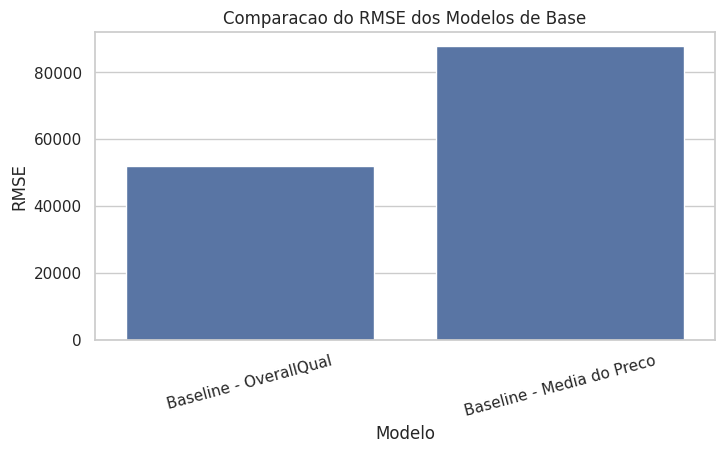

In [25]:
# Converte a lista de resultados em um DataFrame para facilitar a visualizacao.
baseline_results = pd.DataFrame(model_results)

# Mantem apenas os resultados dos modelos de base.
baseline_results = baseline_results[baseline_results["Modelo"].str.contains("Baseline")].copy()

# Ordena os baselines pelo menor RMSE.
baseline_results = baseline_results.sort_values(by="RMSE")

# Exibe a tabela com as metricas dos baselines.
display(baseline_results)

# Cria um grafico de barras para comparar o RMSE dos modelos de base.
plt.figure(figsize=(8, 4))
sns.barplot(data=baseline_results, x="Modelo", y="RMSE")

# Define titulo e rotulos do grafico.
plt.title("Comparacao do RMSE dos Modelos de Base")
plt.xlabel("Modelo")
plt.ylabel("RMSE")

# Ajusta a rotacao dos nomes dos modelos para melhorar a leitura.
plt.xticks(rotation=15)
plt.show()

### Treinamento dos Modelos Lineares

Depois dos modelos de base, serao testadas a Regressao Linear e a Ridge Regression usando todas as variaveis preparadas.

Esses modelos utilizam combinacoes lineares das variaveis para prever o preco de venda. Como modelos lineares podem ser influenciados pela escala das variaveis, sera utilizada a versao padronizada dos dados: `X_train_scaled` e `X_valid_scaled`.

A Regressao Linear sera usada como referencia inicial. A Ridge Regression sera usada como uma alternativa regularizada, que pode lidar melhor com o grande numero de colunas criado pelo One-Hot Encoding.

In [26]:
# Importa os modelos lineares que serao avaliados.
from sklearn.linear_model import LinearRegression, Ridge

# Treina e avalia a Regressao Linear usando os dados padronizados.
linear_regression_model = train_and_evaluate_model(
    model_name="Linear Regression",
    model=LinearRegression(),
    X_train_data=X_train_scaled,
    X_valid_data=X_valid_scaled,
    y_train_data=y_train,
    y_valid_data=y_valid
)

# Treina e avalia a Ridge Regression usando os dados padronizados.
# O parametro alpha controla a intensidade da regularizacao.
ridge_model = train_and_evaluate_model(
    model_name="Ridge Regression",
    model=Ridge(alpha=1.0),
    X_train_data=X_train_scaled,
    X_valid_data=X_valid_scaled,
    y_train_data=y_train,
    y_valid_data=y_valid
)

### Visualizacao dos Resultados dos Modelos Lineares

Depois de treinar a Regressao Linear e a Ridge Regression, podemos visualizar os resultados desses dois modelos.

Essa visualizacao parcial ajuda a verificar se os modelos lineares completos superam os modelos de base. No final, todos os modelos serao comparados juntos em uma tabela consolidada.

,Modelo,MAE,RMSE,R2
3,Ridge Regression,19661.332942,29879.481383,0.883606
2,Linear Regression,19707.184114,29917.121285,0.883312


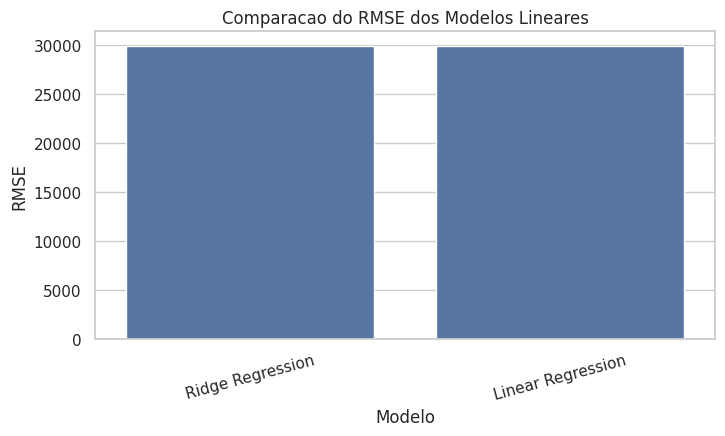

In [27]:
# Converte a lista de resultados em um DataFrame.
linear_results = pd.DataFrame(model_results)

# Mantem apenas os modelos lineares completos.
linear_model_names = ["Linear Regression", "Ridge Regression"]
linear_results = linear_results[linear_results["Modelo"].isin(linear_model_names)].copy()

# Ordena os modelos pelo menor RMSE.
linear_results = linear_results.sort_values(by="RMSE")

# Exibe a tabela com as metricas dos modelos lineares.
display(linear_results)

# Cria um grafico de barras para comparar o RMSE dos modelos lineares.
plt.figure(figsize=(8, 4))
sns.barplot(data=linear_results, x="Modelo", y="RMSE")

# Define titulo e rotulos do grafico.
plt.title("Comparacao do RMSE dos Modelos Lineares")
plt.xlabel("Modelo")
plt.ylabel("RMSE")

# Ajusta a rotacao dos nomes dos modelos para melhorar a leitura.
plt.xticks(rotation=15)
plt.show()

### Treinamento dos Modelos Baseados em Arvores

Agora serao testados modelos baseados em arvores de decisao.

Diferente dos modelos lineares, esses modelos conseguem capturar relacoes nao lineares e interacoes entre variaveis. Por exemplo, o efeito de uma garagem pode ser diferente dependendo da qualidade geral do imovel, da area construida ou do bairro.

Outra diferenca importante e que modelos baseados em arvores geralmente nao precisam de padronizacao das variaveis. Por isso, nesta etapa sera utilizada a versao codificada, mas nao padronizada, dos dados: `X_train_encoded` e `X_valid_encoded`.

Serao avaliados tres modelos: uma arvore de decisao simples, uma Random Forest e um Gradient Boosting.

In [28]:
# Importa os modelos baseados em arvores que serao avaliados.
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Treina e avalia uma arvore de decisao simples.
decision_tree_model = train_and_evaluate_model(
    model_name="Decision Tree",
    model=DecisionTreeRegressor(random_state=42),
    X_train_data=X_train_encoded,
    X_valid_data=X_valid_encoded,
    y_train_data=y_train,
    y_valid_data=y_valid
)

# Treina e avalia uma Random Forest.
random_forest_model = train_and_evaluate_model(
    model_name="Random Forest",
    model=RandomForestRegressor(n_estimators=100, random_state=42),
    X_train_data=X_train_encoded,
    X_valid_data=X_valid_encoded,
    y_train_data=y_train,
    y_valid_data=y_valid
)

# Treina e avalia um Gradient Boosting Regressor.
gradient_boosting_model = train_and_evaluate_model(
    model_name="Gradient Boosting",
    model=GradientBoostingRegressor(random_state=42),
    X_train_data=X_train_encoded,
    X_valid_data=X_valid_encoded,
    y_train_data=y_train,
    y_valid_data=y_valid
)

### Visualizacao dos Resultados dos Modelos Baseados em Arvores

Depois de treinar os modelos baseados em arvores, podemos visualizar os resultados parciais desse grupo.

Essa visualizacao ajuda a comparar uma arvore simples com modelos de conjunto, como Random Forest e Gradient Boosting. Em geral, espera-se que os modelos de conjunto sejam mais robustos do que uma unica arvore de decisao.

,Modelo,MAE,RMSE,R2
6,Gradient Boosting,17263.214859,27533.503121,0.901165
5,Random Forest,17259.973185,28554.825906,0.893697
4,Decision Tree,28283.510274,42710.680570,0.762174


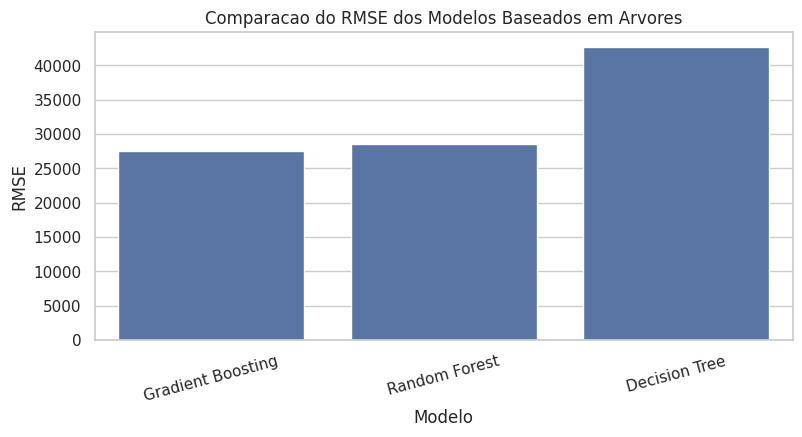

In [29]:
# Converte a lista de resultados em um DataFrame.
tree_results = pd.DataFrame(model_results)

# Mantem apenas os modelos baseados em arvores.
tree_model_names = ["Decision Tree", "Random Forest", "Gradient Boosting"]
tree_results = tree_results[tree_results["Modelo"].isin(tree_model_names)].copy()

# Ordena os modelos pelo menor RMSE.
tree_results = tree_results.sort_values(by="RMSE")

# Exibe a tabela com as metricas dos modelos baseados em arvores.
display(tree_results)

# Cria um grafico de barras para comparar o RMSE dos modelos baseados em arvores.
plt.figure(figsize=(9, 4))
sns.barplot(data=tree_results, x="Modelo", y="RMSE")

# Define titulo e rotulos do grafico.
plt.title("Comparacao do RMSE dos Modelos Baseados em Arvores")
plt.xlabel("Modelo")
plt.ylabel("RMSE")

# Ajusta a rotacao dos nomes dos modelos para melhorar a leitura.
plt.xticks(rotation=15)
plt.show()

### Comparacao Consolidada dos Modelos

Depois de avaliar os modelos de base, os modelos lineares e os modelos baseados em arvores, podemos comparar todos em uma unica tabela.

A comparacao consolidada permite identificar qual tecnica apresentou melhor desempenho no conjunto de validacao. A ordenacao sera feita pelo `RMSE`, pois esta foi definida como a principal metrica de avaliacao.

Quanto menor o `RMSE`, menor foi o erro do modelo nas previsoes. Tambem sera observado o `MAE`, por ser uma metrica facil de interpretar em dolares, e o `R2`, que indica a proporcao da variacao dos precos explicada pelo modelo.

,Modelo,MAE,RMSE,R2
0,Gradient Boosting,17263.214859,27533.503121,0.901165
1,Random Forest,17259.973185,28554.825906,0.893697
2,Ridge Regression,19661.332942,29879.481383,0.883606
3,Linear Regression,19707.184114,29917.121285,0.883312
4,Decision Tree,28283.510274,42710.680570,0.762174
5,Baseline - OverallQual,33343.242087,51778.626512,0.650468
6,Baseline - Media do Preco,62575.926452,87619.034506,-0.000882


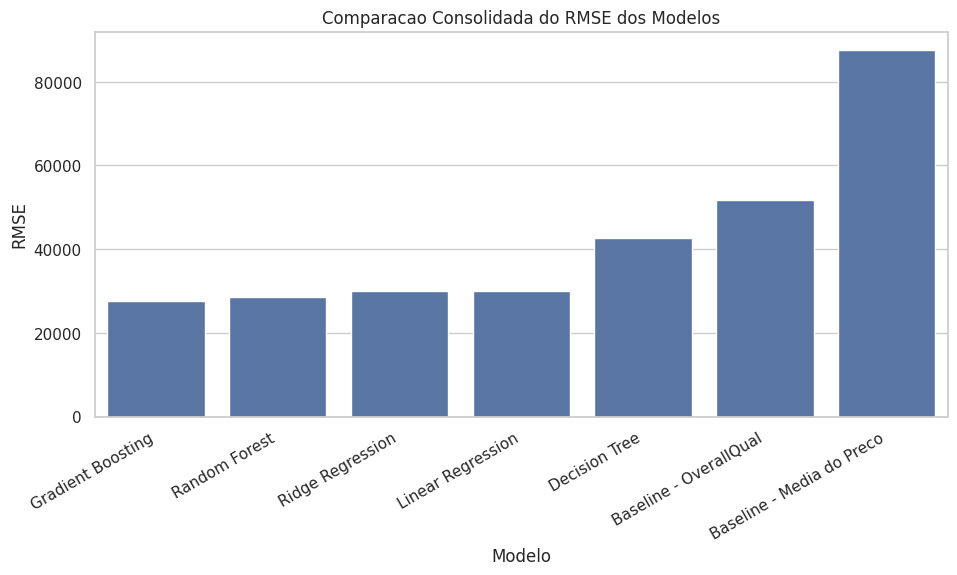

In [30]:
# Converte todos os resultados acumulados em um DataFrame.
all_model_results = pd.DataFrame(model_results)

# Ordena todos os modelos pelo menor RMSE.
all_model_results = all_model_results.sort_values(by="RMSE").reset_index(drop=True)

# Exibe a tabela consolidada com todos os modelos avaliados.
display(all_model_results)

# Cria um grafico de barras comparando o RMSE de todos os modelos.
plt.figure(figsize=(11, 5))
sns.barplot(data=all_model_results, x="Modelo", y="RMSE")

# Define titulo e rotulos do grafico.
plt.title("Comparacao Consolidada do RMSE dos Modelos")
plt.xlabel("Modelo")
plt.ylabel("RMSE")

# Ajusta a rotacao dos nomes dos modelos para melhorar a leitura.
plt.xticks(rotation=30, ha="right")
plt.show()

### Visualizacao das Tres Metricas de Avaliacao

O grafico anterior usa o `RMSE` porque ele foi definido como metrica principal para ordenar os modelos.

Mesmo assim, e uma boa pratica observar outras metricas antes de escolher o modelo final. Por isso, a seguir serao exibidos tres graficos lado a lado: `MAE`, `RMSE` e `R2`.

Nos graficos de `MAE` e `RMSE`, valores menores indicam melhor desempenho. No grafico de `R2`, valores maiores indicam melhor desempenho.

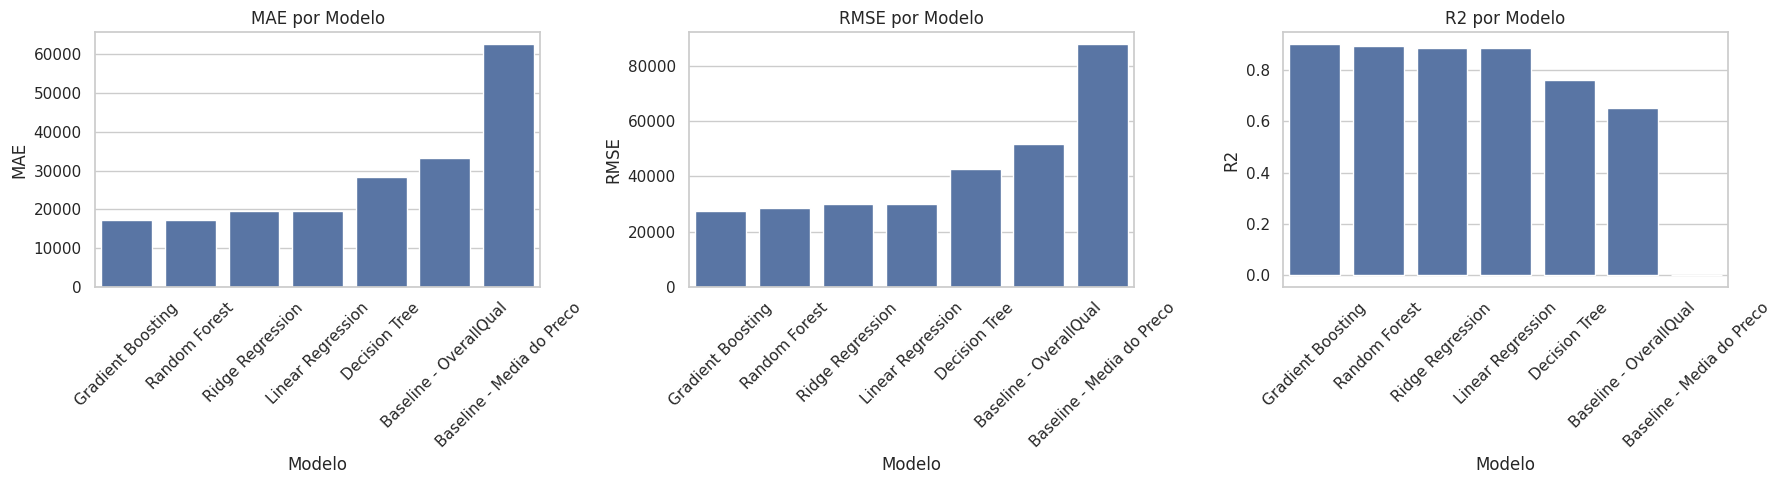

In [31]:
# Cria uma figura com tres graficos lado a lado.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Grafico do MAE: quanto menor, melhor.
sns.barplot(data=all_model_results, x="Modelo", y="MAE", ax=axes[0])
axes[0].set_title("MAE por Modelo")
axes[0].set_xlabel("Modelo")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=45)

# Grafico do RMSE: quanto menor, melhor.
sns.barplot(data=all_model_results, x="Modelo", y="RMSE", ax=axes[1])
axes[1].set_title("RMSE por Modelo")
axes[1].set_xlabel("Modelo")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=45)

# Grafico do R2: quanto maior, melhor.
sns.barplot(data=all_model_results, x="Modelo", y="R2", ax=axes[2])
axes[2].set_title("R2 por Modelo")
axes[2].set_xlabel("Modelo")
axes[2].set_ylabel("R2")
axes[2].tick_params(axis="x", rotation=45)

# Ajusta o espacamento entre os graficos para evitar sobreposicao de textos.
plt.tight_layout()
plt.show()

### Escolha do Modelo Final

Apos comparar todos os modelos no conjunto de validacao, o melhor desempenho foi obtido pelo **Gradient Boosting Regressor**.

Esse modelo apresentou o menor `RMSE`, que foi definido como a principal metrica de avaliacao. Alem disso, tambem apresentou um `MAE` baixo e o maior valor de `R2` entre os modelos testados.

Comparado ao baseline pela media, o Gradient Boosting reduziu bastante o erro de previsao. Comparado ao baseline com `OverallQual`, tambem houve uma melhora significativa, mostrando que utilizar varias caracteristicas do imovel trouxe ganho real para o modelo.

O resultado tambem indica que modelos capazes de capturar relacoes nao lineares e interacoes entre variaveis podem ser mais adequados para este problema do que modelos lineares simples.

Por isso, o **Gradient Boosting Regressor** sera escolhido como modelo final para gerar as previsoes no conjunto `test.csv`.

### Validacao Cruzada do Modelo Escolhido

Ate este momento, os modelos foram avaliados usando uma unica divisao entre treino e validacao.

Essa estrategia permite comparar os modelos, mas o resultado pode depender da forma como os dados foram divididos. Para ter uma avaliacao mais robusta, sera utilizada a validacao cruzada.

Na validacao cruzada, o conjunto de dados e dividido em varias partes. O modelo e treinado em algumas partes e validado em outra, repetindo esse processo varias vezes. Assim, obtemos uma media de desempenho mais confiavel.

Neste projeto, a validacao cruzada sera aplicada ao modelo escolhido, o **Gradient Boosting Regressor**, usando a metrica `RMSE`.

Como o pre-processamento foi feito manualmente antes desta etapa, esta validacao cruzada sera usada como uma aproximacao didatica. Em um projeto de producao, o ideal seria colocar o pre-processamento e o modelo dentro de um `Pipeline`, para garantir que cada dobra da validacao cruzada ajuste suas transformacoes apenas com os dados de treino daquela dobra.

In [32]:
# Importa a funcao de validacao cruzada.
from sklearn.model_selection import cross_val_score

# Reune novamente treino e validacao em um unico conjunto ja codificado.
# Isso permite avaliar o modelo escolhido usando diferentes divisoes dos dados.
X_cross_validation = pd.concat([X_train_encoded, X_valid_encoded], axis=0)
y_cross_validation = pd.concat([y_train, y_valid], axis=0)

# Cria uma nova instancia do modelo escolhido.
gradient_boosting_cv_model = GradientBoostingRegressor(random_state=42)

# Calcula a validacao cruzada usando 5 dobras.
# O scikit-learn retorna o erro quadratico medio negativo, por isso usamos o sinal negativo depois.
negative_mse_scores = cross_val_score(
    gradient_boosting_cv_model,
    X_cross_validation,
    y_cross_validation,
    cv=5,
    scoring="neg_mean_squared_error"
)

# Converte os resultados para RMSE positivo.
rmse_scores = np.sqrt(-negative_mse_scores)

# Exibe os resultados de cada dobra e a media final.
print("RMSE em cada dobra:", rmse_scores)
print("RMSE medio:", rmse_scores.mean())
print("Desvio padrao do RMSE:", rmse_scores.std())

RMSE em cada dobra: [21978.86662016 47685.11485806 26917.61574197 20568.67394849
 27533.50312062]
RMSE medio: 28936.754857861477
Desvio padrao do RMSE: 9756.885033024619


### Validacao Cruzada com Dobras Embaralhadas

Na primeira validacao cruzada, uma das dobras apresentou um `RMSE` bem maior do que as demais. Isso indica que aquela parte dos dados pode ter concentrado exemplos mais dificeis de prever, como imoveis com caracteristicas raras, valores extremos ou combinacoes pouco comuns.

Tambem e importante observar que, quando usamos `cv=5` diretamente no `cross_val_score`, as dobras sao formadas de maneira sequencial, seguindo a ordem dos dados.

Para testar uma abordagem mais robusta, sera feita uma nova validacao cruzada usando `KFold` com `shuffle=True`. Assim, os dados sao embaralhados antes de formar as dobras. O parametro `random_state=42` garante que esse embaralhamento possa ser reproduzido.

In [33]:
# Importa o KFold para controlar como as dobras da validacao cruzada serao formadas.
from sklearn.model_selection import KFold

# Cria uma estrategia de validacao cruzada com 5 dobras embaralhadas.
kfold_shuffled = KFold(n_splits=5, shuffle=True, random_state=42)

# Cria uma nova instancia do modelo escolhido.
gradient_boosting_shuffled_cv_model = GradientBoostingRegressor(random_state=42)

# Calcula a validacao cruzada com dobras embaralhadas.
negative_mse_scores_shuffled = cross_val_score(
    gradient_boosting_shuffled_cv_model,
    X_cross_validation,
    y_cross_validation,
    cv=kfold_shuffled,
    scoring="neg_mean_squared_error"
)

# Converte os resultados para RMSE positivo.
rmse_scores_shuffled = np.sqrt(-negative_mse_scores_shuffled)

# Exibe os resultados de cada dobra e a media final.
print("RMSE em cada dobra embaralhada:", rmse_scores_shuffled)
print("RMSE medio com dobras embaralhadas:", rmse_scores_shuffled.mean())
print("Desvio padrao do RMSE com dobras embaralhadas:", rmse_scores_shuffled.std())

RMSE em cada dobra embaralhada: [33423.36274367 27163.76134568 22937.30906111 34573.43135837
 21023.2678683 ]
RMSE medio com dobras embaralhadas: 27824.22647542649
Desvio padrao do RMSE com dobras embaralhadas: 5430.89877423869


### Treinamento Final e Geracao da Submissao

Depois da comparacao dos modelos e da validacao cruzada, o **Gradient Boosting Regressor** foi escolhido como modelo final.

Ate agora, parte do `train.csv` foi separada para validacao. Para gerar a submissao do Kaggle, o modelo final sera treinado novamente usando todos os dados disponiveis de treino.

Em seguida, o modelo sera aplicado ao `test.csv`, que contem as casas sem a coluna `SalePrice`. As previsoes geradas serao organizadas no mesmo formato do arquivo `sample_submission.csv`, com as colunas `Id` e `SalePrice`.

O arquivo final podera ser enviado ao Kaggle para avaliacao no ranking da competicao.

In [34]:
# Reune novamente treino e validacao para treinar o modelo final com todos os dados disponiveis do train.csv.
X_full_encoded = pd.concat([X_train_encoded, X_valid_encoded], axis=0)
y_full = pd.concat([y_train, y_valid], axis=0)

# Cria uma nova instancia do modelo final escolhido.
final_model = GradientBoostingRegressor(random_state=42)

# Treina o modelo final usando todos os dados de treino disponiveis.
final_model.fit(X_full_encoded, y_full)

# Gera previsoes para o conjunto de teste do Kaggle.
test_predictions = final_model.predict(X_test_encoded)

# Cria o arquivo de submissao no mesmo formato do sample_submission.csv.
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": test_predictions
})

# Salva o arquivo CSV que pode ser enviado ao Kaggle.
submission.to_csv("submission_gradient_boosting.csv", index=False)

# Exibe as primeiras linhas da submissao para conferencia.
submission.head()

,Id,SalePrice
0,1461,121784.399992
1,1462,161698.442177
2,1463,178919.932133
3,1464,180693.414476
4,1465,197789.198382


### Resultado da Submissao no Kaggle

A submissao gerada pelo modelo **Gradient Boosting Regressor** obteve score **0.13682** no Kaggle.

Esse resultado e bom para uma primeira abordagem didatica do problema, principalmente considerando que o modelo foi construido com pre-processamento manual e sem uma etapa extensa de ajuste de hiperparametros.

E importante observar que o score do Kaggle nao e o mesmo `RMSE` em dolares utilizado durante a avaliacao interna do notebook. Nesta competicao, o Kaggle utiliza uma metrica baseada em logaritmo, geralmente conhecida como `RMSLE` (*Root Mean Squared Log Error*). Nessa metrica, valores menores indicam melhor desempenho.

Como trabalho futuro, seria possivel tentar melhorar esse score testando modelos mais avancados, como XGBoost, LightGBM ou CatBoost, ajustando hiperparametros e utilizando `Pipeline` para organizar melhor o pre-processamento e a validacao cruzada.

Mesmo assim, o resultado obtido ja demonstra que o modelo conseguiu aprender padroes relevantes dos dados e gerar previsoes consistentes para o conjunto de teste.